<a href="https://colab.research.google.com/github/MatiasO2312/AA---Tierra-del-Fuego---Parque-Nacional/blob/main/notebooks/02_modelo_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de Clasificación — Parque Nacional Tierra del Fuego

Este notebook implementa el pipeline completo de Aprendizaje Automático para predecir:
- `nivel_temporada`: nivel de actividad turística del mes siguiente (Alta / Media / Baja)
- `perfil_visitante`: tipo de visitante predominante el mes siguiente (Residente / No Residente)

**Fuente de datos:** IPIEC — Instituto Provincial de Análisis e Investigación, Estadística
y Censos de Tierra del Fuego.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

In [2]:
uploaded = files.upload()
# Subimos los 3 archivos

Saving 22_2_01_Meteorologia_Temperatura_Precipitaciones.xlsx to 22_2_01_Meteorologia_Temperatura_Precipitaciones.xlsx
Saving 16_1_04_Visitas-al-Parque-Nacional-TDF.xlsx to 16_1_04_Visitas-al-Parque-Nacional-TDF.xlsx
Saving 16_1_01_Pernoctaciones_ingresos_estadia_promedio.xlsx to 16_1_01_Pernoctaciones_ingresos_estadia_promedio.xlsx


## Decisiones de preprocesamiento

Antes de cargar los datos se definen las siguientes decisiones metodológicas:

- **2020 excluido** en los 3 datasets: el Parque Nacional estuvo cerrado por COVID-19,
  generando una anomalía estructural que distorsionaría los patrones estacionales.
- **Meteorología Ushuaia 2024**: datos faltantes en IPIEC. Se usan las variables de
  Río Grande como proxy (misma provincia, comportamiento climático similar).
- **Período final de trabajo**: 2015–2025 excluyendo 2020.
- **Lag de 1 mes**: las features del mes actual se usan para predecir el mes siguiente.

# Carga y Limpieza del dataset

In [3]:
# ── Dataset 1: Visitas ────────────────────────────────────────────────────
df_v = pd.read_excel('16_1_04_Visitas-al-Parque-Nacional-TDF.xlsx',
                     sheet_name='16_1_04', skiprows=4, header=None)
df_v.columns = ['año', 'mes', 'total_visitas', 'drop', 'residentes', 'no_residentes']
df_v = df_v.drop(columns=['drop'])
df_v['año'] = df_v['año'].ffill()
df_v = df_v[df_v['mes'].notna() & df_v['total_visitas'].notna()]
for col in ['total_visitas', 'residentes', 'no_residentes']:
    df_v[col] = pd.to_numeric(df_v[col], errors='coerce')
df_v['año'] = pd.to_numeric(df_v['año'], errors='coerce').astype('Int64')
df_v = df_v[(df_v['año'] >= 2015) & (df_v['año'] != 2020)]
df_v['mes'] = df_v['mes'].astype(str).str.strip().str.lower()

# ── Dataset 2: Meteorología ───────────────────────────────────────────────
df_m = pd.read_excel('22_2_01_Meteorologia_Temperatura_Precipitaciones.xlsx',
                     sheet_name='por mes', skiprows=8, header=None)
df_m.columns = ['año','mes','rg_temp_max','rg_temp_min','rg_temp_media','_1','_2',
                'rg_lluvia_mm','rg_dias_nieve','_3',
                'ush_temp_max','ush_temp_min','ush_temp_media','_4',
                'ush_lluvia_mm','ush_dias_nieve']
df_m = df_m[['año','mes','rg_temp_max','rg_temp_min','rg_temp_media','rg_lluvia_mm',
             'ush_temp_max','ush_temp_min','ush_temp_media','ush_lluvia_mm']]
df_m['año'] = df_m['año'].ffill()
df_m['mes'] = df_m['mes'].astype(str).str.strip().str.lower()
meses = ['enero','febrero','marzo','abril','mayo','junio',
         'julio','agosto','septiembre','octubre','noviembre','diciembre']
df_m = df_m[df_m['mes'].isin(meses)]
for col in df_m.columns:
    if col != 'mes':
        df_m[col] = pd.to_numeric(df_m[col], errors='coerce')
df_m['año'] = df_m['año'].astype(int)
df_m = df_m[(df_m['año'] >= 2015) & (df_m['año'] != 2020)]

# Proxy: Ushuaia 2024 usa Río Grande
mask_2024 = df_m['año'] == 2024
df_m.loc[mask_2024, 'ush_temp_max']   = df_m.loc[mask_2024, 'rg_temp_max']
df_m.loc[mask_2024, 'ush_temp_min']   = df_m.loc[mask_2024, 'rg_temp_min']
df_m.loc[mask_2024, 'ush_temp_media'] = df_m.loc[mask_2024, 'rg_temp_media']
df_m.loc[mask_2024, 'ush_lluvia_mm']  = df_m.loc[mask_2024, 'rg_lluvia_mm']

# ── Dataset 3: Pernoctaciones ─────────────────────────────────────────────
meses_l = meses

def cargar_hoja(sheet):
    df = pd.read_excel('16_1_01_Pernoctaciones_ingresos_estadia_promedio.xlsx',
                       sheet_name=sheet, header=None)
    for i, row in df.iterrows():
        if row.astype(str).str.contains('Total').sum() >= 2:
            fila_inicio = i + 1
            break
    df = pd.read_excel('16_1_01_Pernoctaciones_ingresos_estadia_promedio.xlsx',
                       sheet_name=sheet, skiprows=fila_inicio, header=None)
    df = df.iloc[:, [0, 1, 2, 7, 12]].copy()
    df.columns = ['año','mes','ush_pern_total','ush_viaj_total','ush_estadia_total']
    df['año'] = df['año'].ffill()
    df['mes'] = df['mes'].astype(str).str.strip().str.lower()
    df = df[df['mes'].isin(meses_l)]
    for col in ['ush_pern_total','ush_viaj_total','ush_estadia_total']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df['año'] = pd.to_numeric(df['año'], errors='coerce').astype('Int64')
    return df

df_p = pd.concat([cargar_hoja('por mes 2004-2011'),
                  cargar_hoja('por mes 2012-2023'),
                  cargar_hoja('por mes 2024 en adelante')], ignore_index=True)
df_p = df_p[(df_p['año'] >= 2015) & (df_p['año'] != 2020)]

print(f"Visitas:        {len(df_v)} filas")
print(f"Meteorología:   {len(df_m)} filas")
print(f"Pernoctaciones: {len(df_p)} filas")

Visitas:        123 filas
Meteorología:   120 filas
Pernoctaciones: 117 filas


# Merge de los 3 datasets

In [4]:
df_m['año'] = df_m['año'].astype('Int64')

df = df_v.merge(df_m, on=['año','mes'], how='inner')
df = df.merge(df_p, on=['año','mes'], how='inner')

print(f"Dataset combinado: {df.shape[0]} filas x {df.shape[1]} columnas")
print(df.head())

Dataset combinado: 117 filas x 16 columnas
    año      mes  total_visitas  residentes  no_residentes  rg_temp_max  \
0  2015    enero        60841.0     36642.0        24199.0         16.7   
1  2015  febrero        43944.0     20800.0        23144.0         16.3   
2  2015    marzo        29554.0     16253.0        13301.0         15.1   
3  2015    abril        12992.0      8820.0         4172.0         11.2   
4  2015     mayo         8778.0      6220.0         2558.0          7.2   

   rg_temp_min  rg_temp_media  rg_lluvia_mm  ush_temp_max  ush_temp_min  \
0          5.6           11.3           5.9          14.3           5.3   
1          5.5           10.5          26.1          13.9           4.6   
2          6.0            9.8          19.4          13.9           4.7   
3          1.6            5.7          41.9          10.2           2.2   
4          1.0            3.8          78.0           6.4           0.5   

   ush_temp_media  ush_lluvia_mm  ush_pern_total  ush_v

# Construcción de los targets con lag

In [5]:
# Ordenar cronológicamente
orden_meses = {m: i for i, m in enumerate(meses)}
df['mes_num'] = df['mes'].map(orden_meses)
df = df.sort_values(['año','mes_num']).reset_index(drop=True)

# Lag: el target es el total_visitas del MES SIGUIENTE
df['visitas_siguiente'] = df['total_visitas'].shift(-1)
df['no_res_siguiente']  = df['no_residentes'].shift(-1)
df['res_siguiente']     = df['residentes'].shift(-1)

# Target 1: nivel_temporada (Alta / Media / Baja por terciles)
p33 = df['visitas_siguiente'].quantile(0.33)
p66 = df['visitas_siguiente'].quantile(0.66)

def clasificar_nivel(v):
    if v <= p33:   return 'Baja'
    elif v <= p66: return 'Media'
    else:          return 'Alta'

df['nivel_temporada'] = df['visitas_siguiente'].apply(clasificar_nivel)

# Target 2: perfil_visitante (No_Residente si predominan, sino Residente)
df['perfil_visitante'] = (df['no_res_siguiente'] > df['res_siguiente']).map(
    {True: 'No_Residente', False: 'Residente'})

# Eliminar la última fila (no tiene "mes siguiente")
df = df.dropna(subset=['visitas_siguiente','no_res_siguiente'])

print(f"Filas finales con targets: {len(df)}")
print("\nDistribución nivel_temporada:")
print(df['nivel_temporada'].value_counts())
print("\nDistribución perfil_visitante:")
print(df['perfil_visitante'].value_counts())

Filas finales con targets: 115

Distribución nivel_temporada:
nivel_temporada
Alta     40
Baja     38
Media    37
Name: count, dtype: int64

Distribución perfil_visitante:
perfil_visitante
Residente       86
No_Residente    29
Name: count, dtype: int64


## **Análisis Exploratorio de Datos (EDA)**

**Se analizan las distribuciones de las variables principales, la estacionalidad
de las visitas y la correlación entre features climáticas y turísticas.**




# Gráfico 1: visitas por mes (estacionalidad)

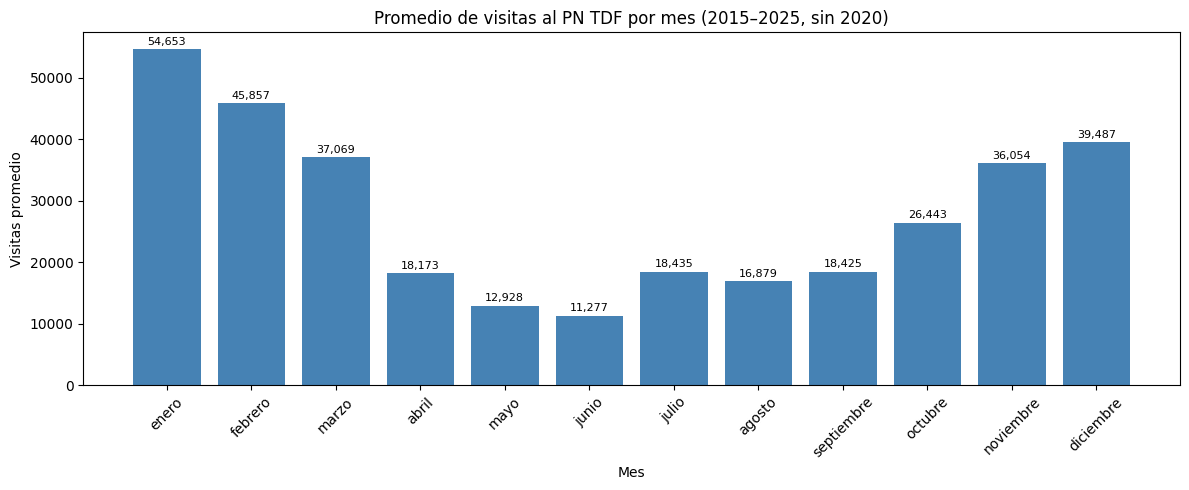

In [6]:
orden_meses = ['enero','febrero','marzo','abril','mayo','junio',
               'julio','agosto','septiembre','octubre','noviembre','diciembre']

visitas_mes = df.groupby('mes')['total_visitas'].mean().reindex(orden_meses)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(orden_meses, visitas_mes, color='steelblue')
for bar, val in zip(bars, visitas_mes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{int(val):,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Promedio de visitas al PN TDF por mes (2015–2025, sin 2020)')
ax.set_xlabel('Mes')
ax.set_ylabel('Visitas promedio')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('estacionalidad_visitas.png', dpi=150)
plt.show()

# Gráfico 2: visitas por año

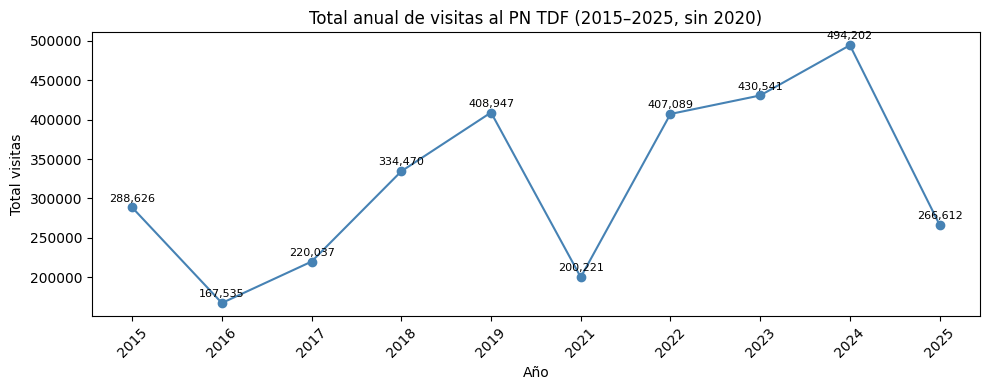

In [7]:
visitas_anio = df.groupby('año')['total_visitas'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(visitas_anio.index.astype(str), visitas_anio.values, marker='o', color='steelblue')
for x, y in zip(visitas_anio.index.astype(str), visitas_anio.values):
    ax.text(x, y + 5000, f'{int(y):,}', ha='center', va='bottom', fontsize=8)
ax.set_title('Total anual de visitas al PN TDF (2015–2025, sin 2020)')
ax.set_xlabel('Año')
ax.set_ylabel('Total visitas')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('visitas_por_anio.png', dpi=150)
plt.show()

# Gráfico 3: distribución de targets

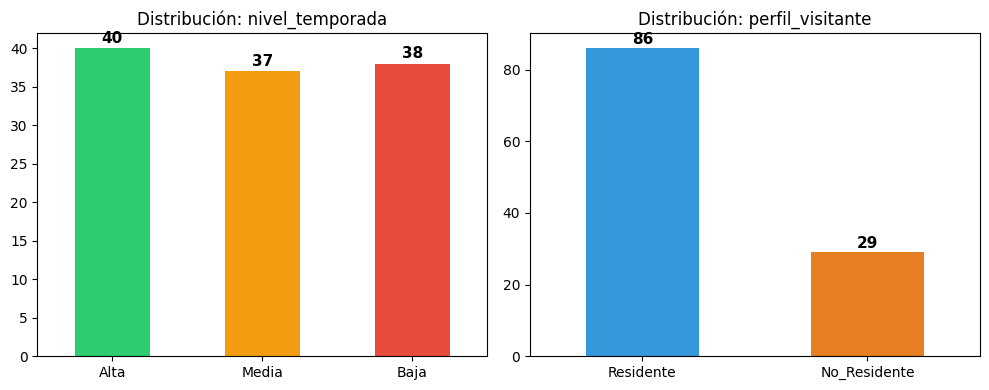

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts_nivel = df['nivel_temporada'].value_counts().reindex(['Alta','Media','Baja'])
bars1 = counts_nivel.plot(kind='bar', ax=axes[0], color=['#2ecc71','#f39c12','#e74c3c'])
for bar, val in zip(axes[0].patches, counts_nivel):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Distribución: nivel_temporada')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

counts_perfil = df['perfil_visitante'].value_counts()
bars2 = counts_perfil.plot(kind='bar', ax=axes[1], color=['#3498db','#e67e22'])
for bar, val in zip(axes[1].patches, counts_perfil):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('Distribución: perfil_visitante')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('distribucion_targets.png', dpi=150)
plt.show()

# Gráfico 4: mapa de correlaciones

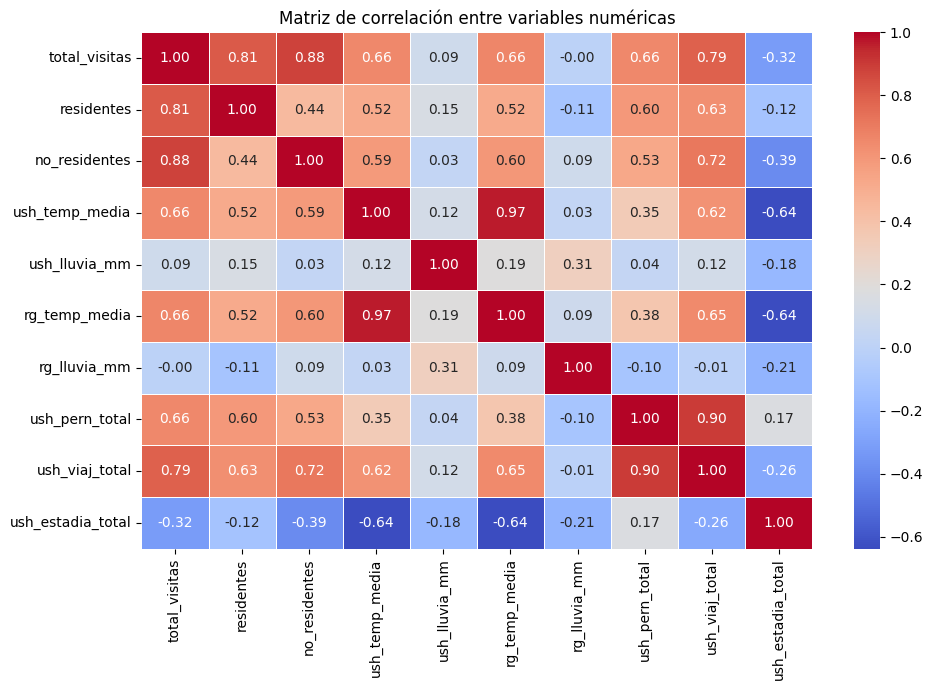

In [9]:
features_numericas = ['total_visitas','residentes','no_residentes',
                      'ush_temp_media','ush_lluvia_mm',
                      'rg_temp_media','rg_lluvia_mm',
                      'ush_pern_total','ush_viaj_total','ush_estadia_total']

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df[features_numericas].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlación entre variables numéricas')
plt.tight_layout()
plt.savefig('correlacion_features.png', dpi=150)
plt.show()

## Conclusiones del EDA

- Las visitas al PN TDF muestran una **fuerte estacionalidad**: los meses de
  verano austral (enero, febrero) concentran la mayor afluencia, mientras que
  los meses de invierno (mayo–agosto) presentan valores mínimos.
- La distribución anual muestra recuperación sostenida tras 2021 (post-COVID).
- La variable `nivel_temporada` quedó distribuida de forma casi equilibrada
  (Alta: 40, Media: 37, Baja: 38), lo que favorece el entrenamiento del modelo.
- La variable `perfil_visitante` presenta desbalance (86 Residentes vs 29 No Residentes),
  lo que puede afectar la precisión del modelo para la clase minoritaria. En meses de baja temporada predominan los residentes (excursionistas locales),  mientras que los no residentes se concentran en verano austral.
- Las variables climáticas de Ushuaia y Río Grande están altamente correlacionadas entre sí, lo que confirma que el uso de Río Grande como proxy para 2024 es válido.
- Las pernoctaciones y visitas al parque muestran alta correlación positiva,
  lo que refuerza la utilidad de incluir pernoctaciones como feature.
- El gráfico anual muestra la caída de 2021 (post-COVID) y la fuerte recuperación hacia 2024 (máximo histórico del período analizado: ~493,000 visitas anuales).

# **MODELADO**

# Preparar features y targets

In [10]:
# Elegimos el target principal: nivel_temporada
target = 'nivel_temporada'

# Features numéricas y categóricas
features_numericas = [
    'total_visitas', 'residentes', 'no_residentes',
    'ush_temp_media', 'ush_lluvia_mm',
    'rg_temp_media', 'rg_lluvia_mm',
    'ush_pern_total', 'ush_viaj_total', 'ush_estadia_total'
]

features_categoricas = ['mes']  # mes actual

X = df[features_numericas + features_categoricas]
y = df[target]

# Train / test (20 % test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape[0])
print("Tamaño test:", X_test.shape[0])
y_train.value_counts(), y_test.value_counts()

Tamaño entrenamiento: 92
Tamaño test: 23


(nivel_temporada
 Alta     32
 Media    30
 Baja     30
 Name: count, dtype: int64,
 nivel_temporada
 Alta     8
 Baja     8
 Media    7
 Name: count, dtype: int64)

# Preprocesamiento (ColumnTransformer + Pipeline)

In [11]:
from sklearn.impute import SimpleImputer

# Para numéricas: primero imputar mediana, luego escalar
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Para categóricas: OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_numericas),
        ('cat', categorical_transformer, features_categoricas)
    ]
)

print("Preprocesador con imputación definido.")

Preprocesador con imputación definido.


# Modelo 1: KNN

=== KNN: métricas en test ===
              precision    recall  f1-score   support

        Alta       1.00      0.88      0.93         8
        Baja       0.71      0.62      0.67         8
       Media       0.56      0.71      0.62         7

    accuracy                           0.74        23
   macro avg       0.76      0.74      0.74        23
weighted avg       0.77      0.74      0.75        23



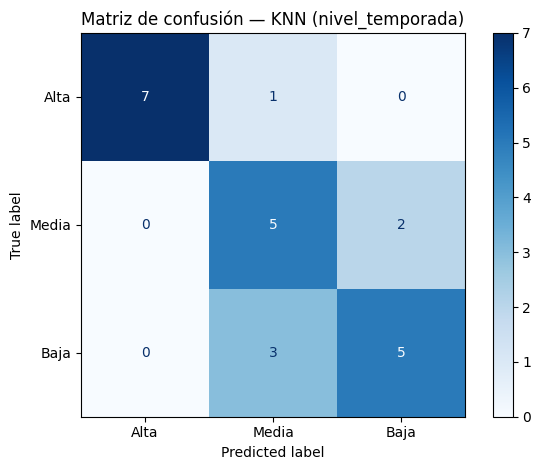

Accuracy CV (5 folds) KNN: 0.67 +/- 0.081


In [12]:
# ── Modelo 1: KNN ─────────────────────────────────────────────────────────
knn_clf = KNeighborsClassifier(n_neighbors=5)

knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', knn_clf)
])

# Entrenamiento
knn_pipeline.fit(X_train, y_train)

# Predicción
y_pred_knn = knn_pipeline.predict(X_test)

print("=== KNN: métricas en test ===")
print(classification_report(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn, labels=['Alta','Media','Baja'])
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                                  display_labels=['Alta','Media','Baja'])
disp_knn.plot(cmap='Blues')
plt.title('Matriz de confusión — KNN (nivel_temporada)')
plt.tight_layout()
plt.savefig('cm_knn_nivel_temporada.png', dpi=150)
plt.show()

# Validación cruzada (solo accuracy) como referencia
scores_knn = cross_val_score(knn_pipeline, X, y, cv=5, scoring='accuracy')
print("Accuracy CV (5 folds) KNN:", scores_knn.mean().round(3), "+/-", scores_knn.std().round(3))

# Modelo 2: Árbol de Decisión

=== Árbol de Decisión: métricas en test ===
              precision    recall  f1-score   support

        Alta       0.67      0.75      0.71         8
        Baja       0.67      0.75      0.71         8
       Media       0.40      0.29      0.33         7

    accuracy                           0.61        23
   macro avg       0.58      0.60      0.58        23
weighted avg       0.59      0.61      0.59        23



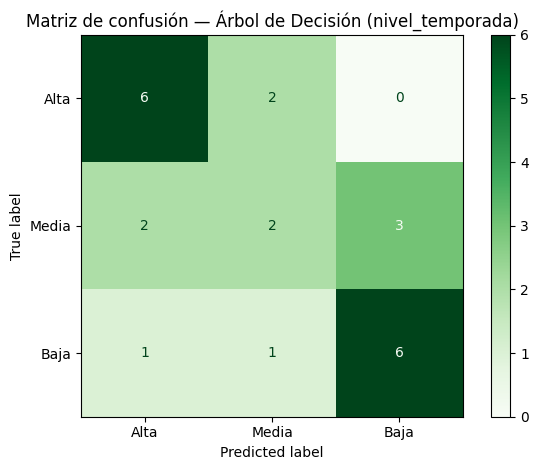

Accuracy CV (5 folds) Árbol: 0.522 +/- 0.055


In [14]:
# ── Modelo 2: Árbol de Decisión ──────────────────────────────────────────
tree_clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', tree_clf)
])

# Entrenamiento
tree_pipeline.fit(X_train, y_train)

# Predicción
y_pred_tree = tree_pipeline.predict(X_test)

print("=== Árbol de Decisión: métricas en test ===")
print(classification_report(y_test, y_pred_tree))

cm_tree = confusion_matrix(y_test, y_pred_tree, labels=['Alta','Media','Baja'])
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree,
                                   display_labels=['Alta','Media','Baja'])
disp_tree.plot(cmap='Greens')
plt.title('Matriz de confusión — Árbol de Decisión (nivel_temporada)')
plt.tight_layout()
plt.savefig('cm_tree_nivel_temporada.png', dpi=150)
plt.show()

scores_tree = cross_val_score(tree_pipeline, X, y, cv=5, scoring='accuracy')
print("Accuracy CV (5 folds) Árbol:", scores_tree.mean().round(3), "+/-", scores_tree.std().round(3))

## Conclusiones sobre el modelo para `nivel_temporada`

Con el dataset combinado (115 instancias mensuales entre 2015 y 2025, excluyendo 2020) se entrenaron dos modelos de clasificación para predecir el `nivel_temporada` (Alta / Media / Baja) del mes siguiente a partir de clima, pernoctaciones y visitas del mes actual.

- El modelo **KNN (k = 5)**, con imputación de medianas, escalado de variables numéricas
  y codificación one-hot del mes, alcanzó en el set de test un **accuracy de 0.74**, con F1-score macro ≈ **0.74**. La validación cruzada (5-fold) reportó un accuracy promedio de **0.67 ± 0.08**, lo que indica un desempeño moderado pero consistente dado el tamaño reducido del dataset.
- El modelo de **Árbol de Decisión (profundidad máxima 4)** obtuvo un accuracy de 0.61 en test y 0.52 en validación cruzada, por debajo de KNN pero con la ventaja de ser más interpretable. Las variables más importantes resultaron ser las visitas del mes actual (`total_visitas`), los viajeros totales y el mes del año, lo que coincide con la intuición de estacionalidad.
- Ambos modelos distinguen bien los meses de **Alta** y **Baja** temporada, pero muestran mayor confusión en la clase **Media**, que corresponde a meses de transición donde el comportamiento turístico es más ambiguo.

En resumen, con un dataset mensual relativamente pequeño, los modelos alcanzan una capacidad de predicción **moderada**, suficiente para identificar meses de alta y baja temporada y apoyar decisiones de planificación, pero limitada para diferenciar con precisión la categoría intermedia.

## Consideración del target `perfil_visitante`

Además de `nivel_temporada`, se evaluó la posibilidad de usar como variable objetivo el `perfil_visitante` del mes siguiente (Residente / No_Residente), es decir, qué tipo de visitante predomina en el parque.

Sin embargo, el análisis exploratorio mostró un **fuerte desbalance de clases**
(86 meses con predominio de residentes vs 29 de no residentes). Con un total de solo 115 observaciones, este desbalance provoca que:

- Un clasificador que prediga siempre "Residente" ya consiga un accuracy alto, pero **no aporta información útil** para identificar los meses en que predominan los no residentes.
- El número de ejemplos "No_Residente" en el conjunto de test es muy reducido,
  lo que hace que las métricas para esta clase sean **inestables y poco robustas** (cambiar uno o dos casos altera fuertemente el resultado).
- El uso de técnicas de balanceo (oversampling, pesos de clase) complicaría el modelo sin agregar demasiada confiabilidad, dado el tamaño general del dataset.

Por este motivo, se decidió **no utilizar `perfil_visitante` como target principal**, sino como variable de análisis complementaria: se describe su distribución, se muestra su desbalance y se propone como línea futura trabajar con más datos o aplicar técnicas específicas de tratamiento de clases desbalanceadas.

## Conclusiones generales

El proyecto integra en un solo dataset la información de visitas al Parque Nacional Tierra del Fuego, clima mensual y pernoctaciones hoteleras a partir de datos oficiales del IPIEC, aplicando decisiones de limpieza justificadas (exclusión de 2020 y uso de Río Grande como proxy climático en 2024). Estas decisiones permiten trabajar con una serie mensual coherente para el período 2015–2025.

Sobre esa base, el análisis exploratorio muestra una estacionalidad clara y relaciones fuertes entre clima, actividad hotelera y visitas al parque, lo que se refleja en el desempeño del modelo: un KNN con preprocesamiento adecuado alcanza un accuracy cercano a 0.67 en validación cruzada para predecir el `nivel_temporada` del mes siguiente, capturando bien los meses de alta y baja temporada y mostrando mayor confusión en la categoría media. El Árbol de Decisión ofrece menor desempeño pero ayuda a interpretar qué variables aportan más información.

Finalmente, se evaluó utilizar `perfil_visitante` como segundo objetivo, pero el desbalance de clases combinado con el tamaño reducido del dataset hace que las métricas para la clase No_Residente sean poco estables. Se documenta esta limitación y se propone trabajar este target en el futuro con más datos y técnicas específicas para desbalance, mientras que en este parcial se prioriza un modelo más sólido y defendible sobre `nivel_temporada`.